<a href="https://colab.research.google.com/github/niharrp06/document_grounding/blob/main/DocuXray_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DocuXray — End-to-End Grounding Pipeline (Colab)

This notebook runs the DocuXray document field grounding pipeline in order:

1. Upload the document image
2. Upload the annotation / field JSON (the fields you want grounded)
3. Generate OCR JSON (PaddleOCR)
4. Run document graph generation (image + OCR JSON)
5. Run the grounding pipeline (image + fields JSON + OCR JSON)
6. Draw grounded boxes on the image

Run the cells top to bottom. Each step's outputs feed directly into the next step.


## Step 0 — Install dependencies

PaddleOCR/PaddlePaddle for OCR, OpenCV for drawing, Pillow for image I/O.

In [1]:
!pip install -q paddlepaddle paddleocr opencv-python-headless pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 1.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.8/146.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/97

## Step 0 (continued) — Upload and set up the DocuXray package

Upload `docuxray_colab.zip` (the DocuXray source package). It will be unzipped to
`/content/docuxray_colab`, and its `src/` directory (containing the importable
`docuxray` package) is added to `sys.path`. No `pip install` is required —
the package only needs `Pillow`, which Colab already has.

In [2]:
from google.colab import files

print("Please select docuxray_colab.zip")
docuxray_zip = files.upload()

Please select docuxray_colab.zip


Saving docuxray_colab.zip to docuxray_colab.zip


In [3]:
import zipfile

zip_name = list(docuxray_zip.keys())[0]

with zipfile.ZipFile(zip_name, "r") as zf:
    zf.extractall("/content")

print(f"Extracted {zip_name} to /content")

Extracted docuxray_colab.zip to /content


In [4]:
import sys

DOCUXRAY_ROOT = "/content/docuxray_colab"

for path in (DOCUXRAY_ROOT, f"{DOCUXRAY_ROOT}/src"):
    if path not in sys.path:
        sys.path.insert(0, path)

import docuxray  # sanity check that the package is importable

print("docuxray package is importable from:", docuxray.__file__)

docuxray package is importable from: /content/docuxray_colab/src/docuxray/__init__.py


## Step 1 — Upload the document image

Please select the document image (e.g. an invoice .png/.jpg)


Saving Cru_CS00418265_page_1.png to Cru_CS00418265_page_1.png
Uploaded image: Cru_CS00418265_page_1.png


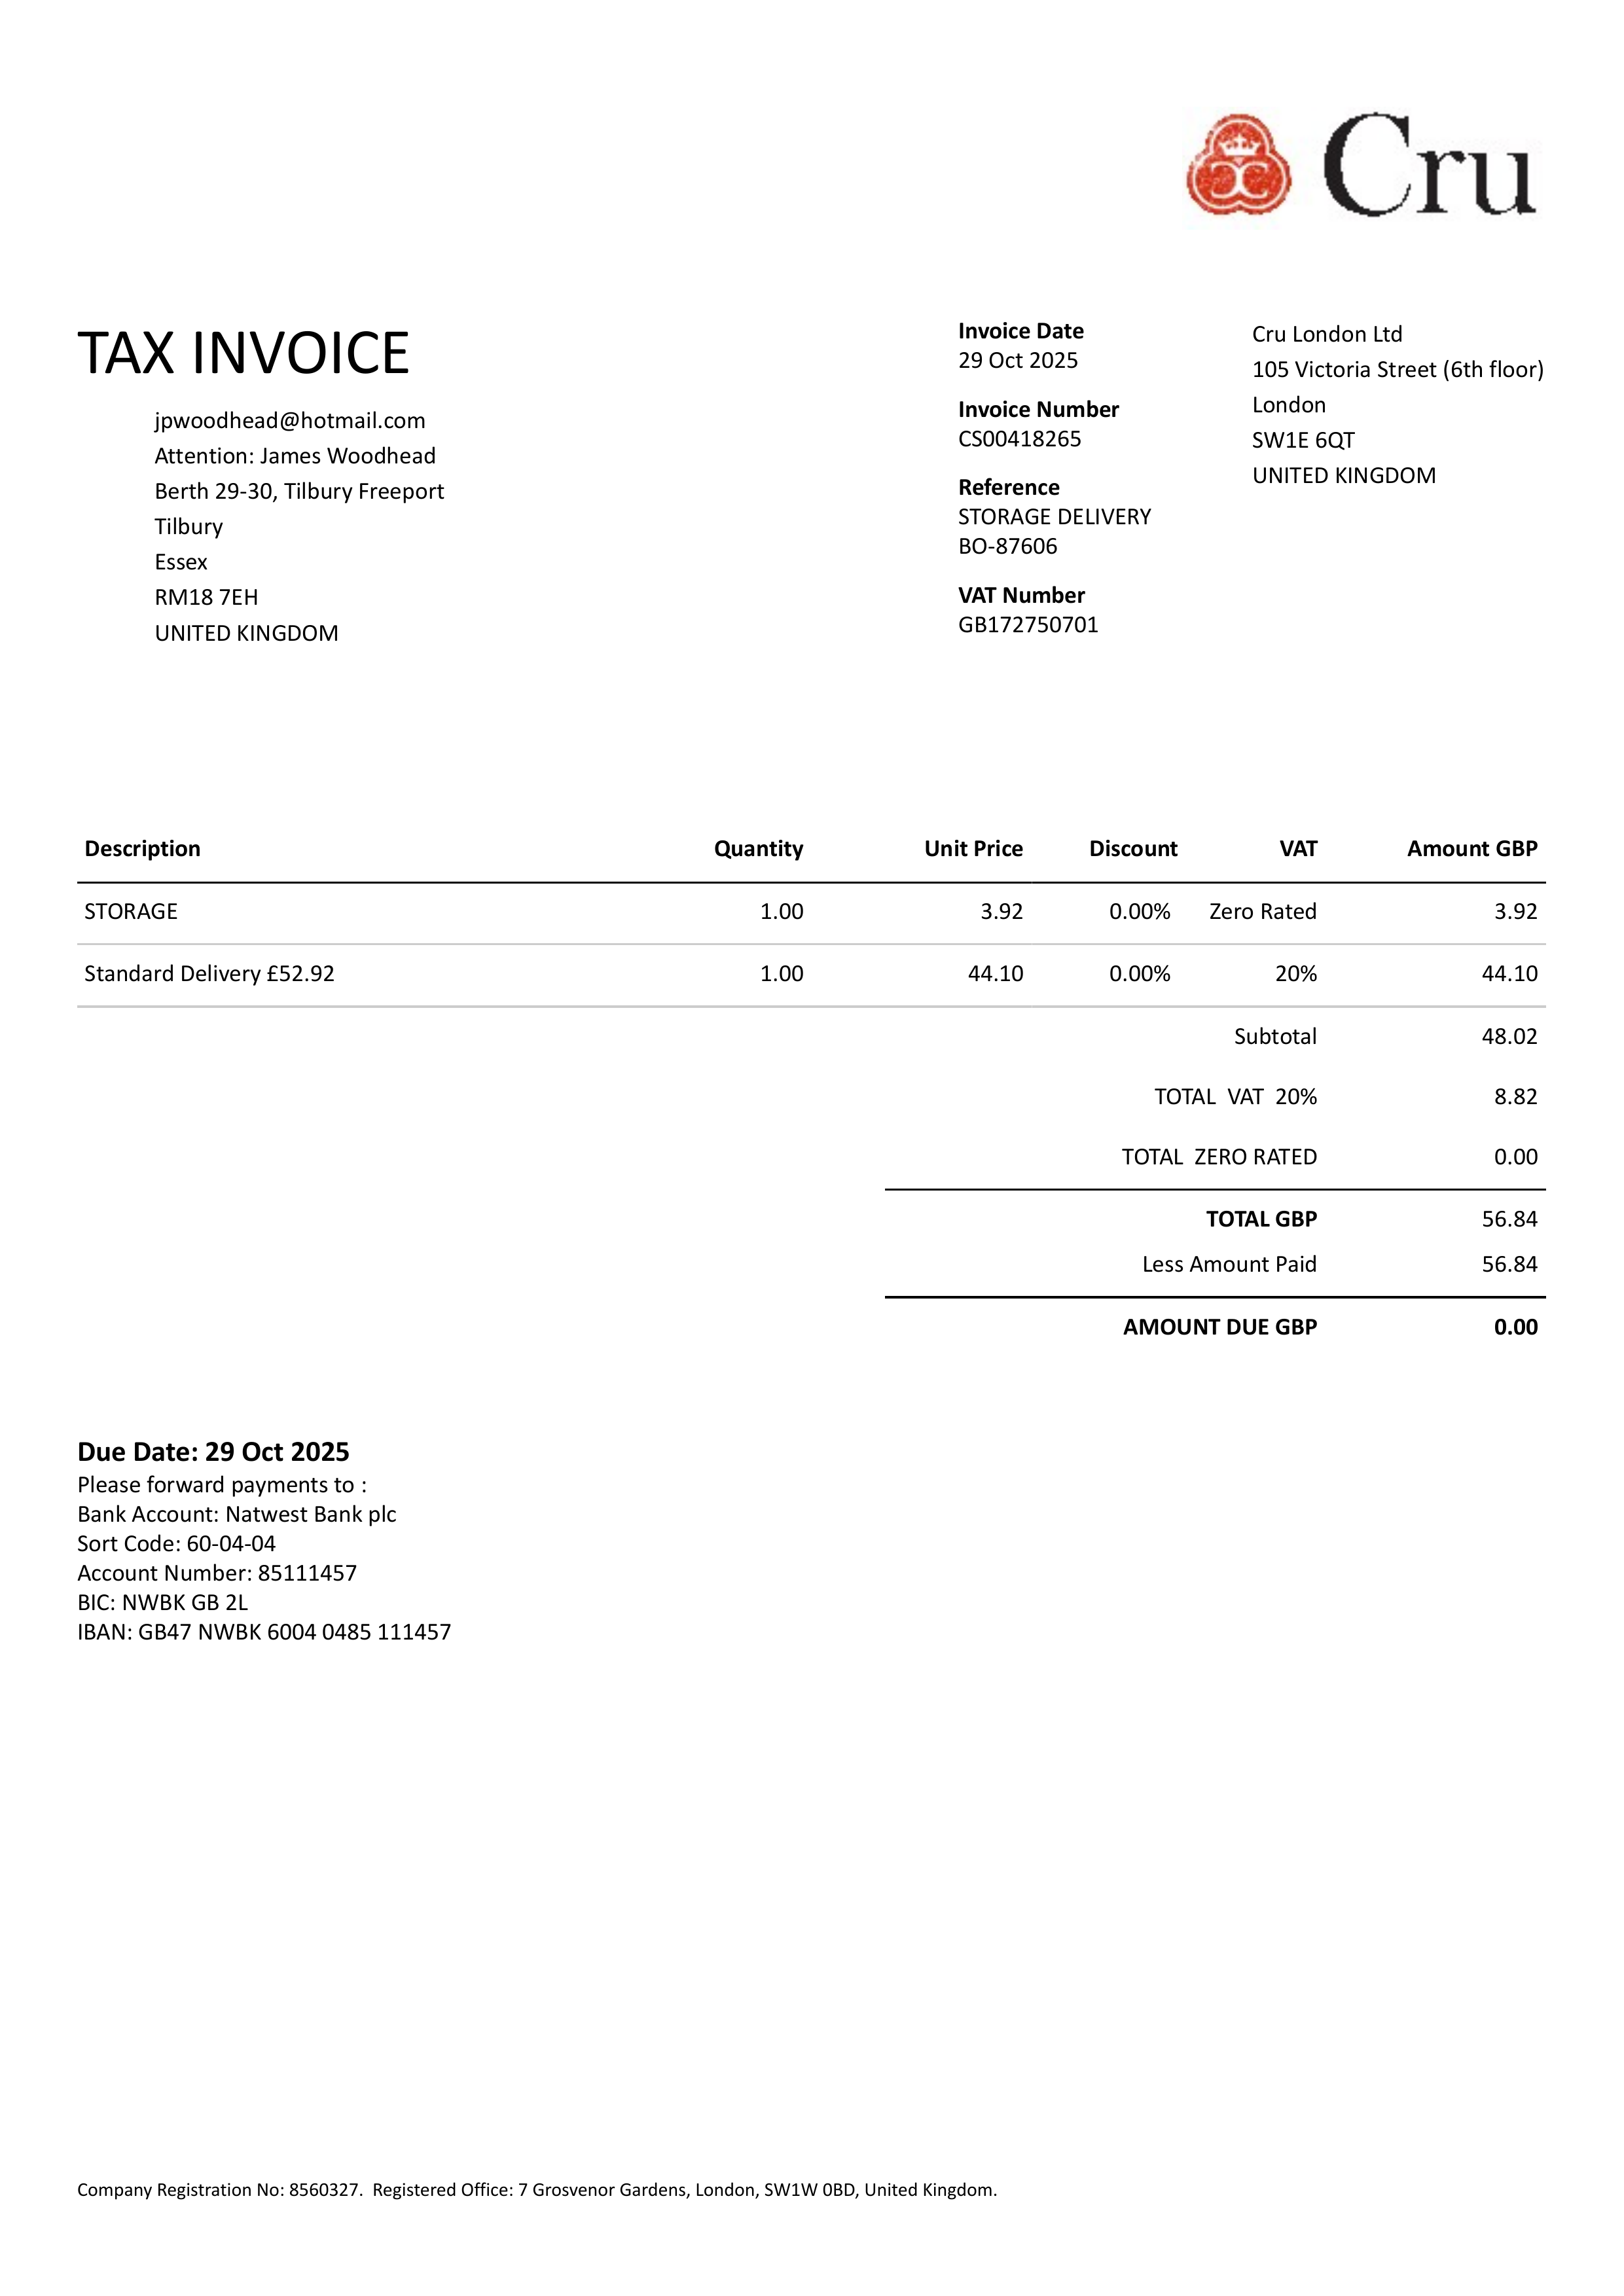

In [5]:
from google.colab import files
from IPython.display import Image, display

print("Please select the document image (e.g. an invoice .png/.jpg)")
uploaded_image = files.upload()

image_path = list(uploaded_image.keys())[0]
print("Uploaded image:", image_path)

display(Image(filename=image_path))

## Step 2 — Upload the annotation / field JSON

This is the requested-fields JSON that DocuXray will try to ground, in the
`{"fields": [...]}` format (also accepts `{"records": [...]}` or a flat
`{"key": "value"}` object — see the DocuXray README for details).

In [6]:
print("Please select the annotation / field JSON")
uploaded_fields = files.upload()

fields_json_path = list(uploaded_fields.keys())[0]
print("Uploaded fields JSON:", fields_json_path)

import json

with open(fields_json_path, "r", encoding="utf-8") as f:
    print(json.dumps(json.load(f), indent=2)[:2000])


Please select the annotation / field JSON


Saving Cru_CS00418265_page_1.json to Cru_CS00418265_page_1.json
Uploaded fields JSON: Cru_CS00418265_page_1.json
{
  "fields": [
    {
      "field_id": "lineitems_0_linetaxpercent_originalvalue",
      "key": "Tax Percent",
      "value": "Zero Rated",
      "metadata": {
        "source_path": "lineItems.0.lineTaxPercent.originalValue",
        "selected_from": "manual_entry"
      },
      "row_index": 0
    },
    {
      "field_id": "totals_taxamount_originalvalue",
      "key": "Tax",
      "value": "8.82",
      "metadata": {
        "source_path": "totals.taxAmount.originalValue",
        "selected_from": "manual_entry"
      }
    },
    {
      "field_id": "totals_taxname",
      "key": "Tax Name",
      "value": "Vat",
      "metadata": {
        "source_path": "totals.taxName",
        "selected_from": "manual_entry"
      }
    },
    {
      "field_id": "totals_taxpercentage_originalvalue",
      "key": "Tax Percentage",
      "value": "20%",
      "metadata": {
        "

## Step 3 — Generate OCR JSON

This runs PaddleOCR on the uploaded image and writes a DocuXray-compatible OCR
JSON (`{"words": [{"id", "text", "box", "confidence", "page"}, ...]}`).

This uses PaddleOCR's modern `predict()` API (PaddleOCR 3.x), not the legacy
`ocr()` API that DocuXray's bundled OCR adapter expects — so we generate the
OCR JSON here ourselves and pass it as `ocr_json_path=` in the later steps,
rather than letting DocuXray call PaddleOCR internally.

In [7]:
import json
from pathlib import Path

from paddleocr import PaddleOCR


def polygon_to_box(points):
    xs = [float(point[0]) for point in points]
    ys = [float(point[1]) for point in points]
    return [
        round(min(xs)),
        round(min(ys)),
        round(max(xs)),
        round(max(ys)),
    ]


def generate_ocr_json(image_path, output_path=None, lang="en", min_confidence=0.0):
    """Run PaddleOCR and write a DocuXray-compatible OCR JSON file."""
    image_path = Path(image_path)

    if output_path is None:
        output_path = f"{image_path.stem}.ocr.json"

    ocr = PaddleOCR(
        lang=lang,
        use_doc_orientation_classify=False,
        use_doc_unwarping=False,
        use_textline_orientation=False,
        enable_mkldnn=False,  # works around a oneDNN/PIR bug in PaddlePaddle 3.3.x
        # (NotImplementedError: ConvertPirAttribute2RuntimeAttribute ...)
    )

    results = ocr.predict(str(image_path))

    words = []
    for page in results:
        rec_texts = page.get("rec_texts", [])
        rec_scores = page.get("rec_scores", [])
        rec_polys = page.get("rec_polys", [])

        for text, score, poly in zip(rec_texts, rec_scores, rec_polys):
            text = str(text).strip()
            if not text or score < min_confidence:
                continue
            words.append(
                {
                    "id": f"w{len(words)}",
                    "text": text,
                    "box": polygon_to_box(poly),
                    "confidence": float(score),
                    "page": 0,
                }
            )

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump({"words": words}, f, indent=2, ensure_ascii=False)

    return str(output_path)


In [9]:
ocr_json_path = generate_ocr_json(image_path, output_path="ocr_output.json")

print("OCR JSON saved to:", ocr_json_path)

with open(ocr_json_path, "r", encoding="utf-8") as f:
    ocr_data = json.load(f)

print(f"Detected {len(ocr_data['words'])} words")
print(json.dumps(ocr_data["words"][:5], indent=2))


Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv6_medium_rec`.


OCR JSON saved to: ocr_output.json
Detected 61 words
[
  {
    "id": "w0",
    "text": "Cru",
    "box": [
      2034,
      180,
      2372,
      362
    ],
    "confidence": 0.9998388290405273,
    "page": 0
  },
  {
    "id": "w1",
    "text": "TAX INVOICE",
    "box": [
      111,
      496,
      631,
      579
    ],
    "confidence": 0.9998897314071655,
    "page": 0
  },
  {
    "id": "w2",
    "text": "Invoice Date",
    "box": [
      1461,
      487,
      1658,
      521
    ],
    "confidence": 0.9999866485595703,
    "page": 0
  },
  {
    "id": "w3",
    "text": "Cru London Ltd",
    "box": [
      1910,
      490,
      2145,
      527
    ],
    "confidence": 0.9996929168701172,
    "page": 0
  },
  {
    "id": "w4",
    "text": "29 Oct 2025",
    "box": [
      1461,
      532,
      1649,
      566
    ],
    "confidence": 0.9999590516090393,
    "page": 0
  }
]


## Step 4 — Run document graph generation

Builds the DocuXray document graph (pages, OCR words, lines, and any table
structure) from the image and the OCR JSON generated in Step 3, and writes it
to `document_graph.json`.

In [10]:
from generate_document_graph import generate_document_graph

document_graph_path = generate_document_graph(
    image_path=image_path,
    ocr_json_path=ocr_json_path,
    output_path="document_graph.json",
)

print("Document graph written to:", document_graph_path)

with open(document_graph_path, "r", encoding="utf-8") as f:
    document_graph = json.load(f)

print("Graph top-level keys:", list(document_graph.keys()))


Document graph written to: document_graph.json
Graph top-level keys: ['pages', 'words', 'lines', 'tables', 'rows', 'cells']


## Step 5 — Run the grounding pipeline

Runs DocuXray's full grounding pipeline using the image, the field requests
JSON from Step 2, and the OCR JSON from Step 3. For each requested field this
returns the matched text, bounding box, confidence, and status
(`matched`, `low_confidence`, `ambiguous`, or `not_found`).

In [11]:
from docuxray.pipeline import run_grounding_pipeline

grounded_fields = run_grounding_pipeline(
    image_path=image_path,
    fields_path=fields_json_path,
    ocr_json_path=ocr_json_path,
    output_graph_path="document_graph_grounded.json",
)

grounded_results = [field.to_dict() for field in grounded_fields]

with open("grounding_results.json", "w", encoding="utf-8") as f:
    json.dump(grounded_results, f, indent=2, ensure_ascii=False)

print(f"Grounded {len(grounded_results)} field(s)")
print(json.dumps(grounded_results, indent=2))


Grounded 40 field(s)
[
  {
    "field_id": "lineitems_0_linetaxpercent_originalvalue",
    "key": "Tax Percent",
    "value": "Zero Rated",
    "matched_text": "Zero Rated",
    "page": 0,
    "bbox": [
      1844,
      1373,
      2014,
      1408
    ],
    "confidence": 0.55,
    "status": "low_confidence",
    "source": "VALUE_ONLY",
    "row_index": null,
    "col_index": null,
    "table_id": null,
    "evidence": {
      "value_match": 1.0,
      "warning": "No key relationship found",
      "candidate_id": "lineitems_0_linetaxpercent_originalvalue:value_only",
      "alternatives": []
    }
  },
  {
    "field_id": "totals_taxamount_originalvalue",
    "key": "Tax",
    "value": "8.82",
    "matched_text": "8.82",
    "page": 0,
    "bbox": [
      2278,
      1655,
      2354,
      1693
    ],
    "confidence": 0.55,
    "status": "low_confidence",
    "source": "VALUE_ONLY",
    "row_index": null,
    "col_index": null,
    "table_id": null,
    "evidence": {
      "value_m

## Step 6 — Draw grounded boxes

Draws the bounding box for each grounded field onto the document image.
Box color reflects the grounding status:

- **green** — `matched`
- **orange** — `low_confidence`
- **yellow** — `ambiguous`
- fields with status `not_found` have no box and are listed separately below.

In [12]:
import cv2

STATUS_COLORS = {
    "matched": (0, 200, 0),        # green (BGR)
    "low_confidence": (0, 165, 255),  # orange
    "ambiguous": (0, 255, 255),    # yellow
}

image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

not_found = []

for result in grounded_results:
    box = result.get("bbox")
    if not box:
        not_found.append(result)
        continue

    x1, y1, x2, y2 = box
    color = STATUS_COLORS.get(result["status"], (255, 0, 0))

    cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

    label = f"{result['key']}={result['value']}"
    label_y = max(y1 - 8, 12)
    cv2.putText(
        image,
        label,
        (x1, label_y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        color,
        1,
        cv2.LINE_AA,
    )

output_image_path = "grounded_boxes.jpg"
cv2.imwrite(output_image_path, image)

print(f"Drew {len(grounded_results) - len(not_found)} box(es)")
print(f"Saved annotated image to: {output_image_path}")

if not_found:
    print("\nFields with no grounded box (status=not_found):")
    for result in not_found:
        print(f"  - {result['key']} = {result['value']} (field_id={result['field_id']})")


Drew 24 box(es)
Saved annotated image to: grounded_boxes.jpg

Fields with no grounded box (status=not_found):
  - Currency = GBP (field_id=currency)
  - Category = Other (field_id=invoiceinfo_category)
  - Due Date = 29 Oct 2025 (field_id=invoiceinfo_duedate)
  - Due Date = 2025-10-29 (field_id=invoiceinfo_duedateiso)
  - Date = 29 Oct 2025 (field_id=invoiceinfo_issuedate)
  - Date = 2025-10-29 (field_id=invoiceinfo_issuedateiso)
  - Invoice Status = paid (field_id=invoicestatus)
  - Quantity = 1.0 (field_id=lineitems_0_quantity_originalvalue)
  - Line Total = 44.1 (field_id=lineitems_1_linetotalexcludingtax_originalvalue)
  - Quantity = 1.0 (field_id=lineitems_1_quantity_originalvalue)
  - Unit Price = 44.1 (field_id=lineitems_1_unitprice_originalvalue)
  - Customer Address = Berth 29-30, Tilbury Freeport (field_id=parties_customer_addressstructured_address)
  - Customer Name = James Woodhead (field_id=parties_customer_name)
  - Seller Address = 105 Victoria Street (6th floor) (field_

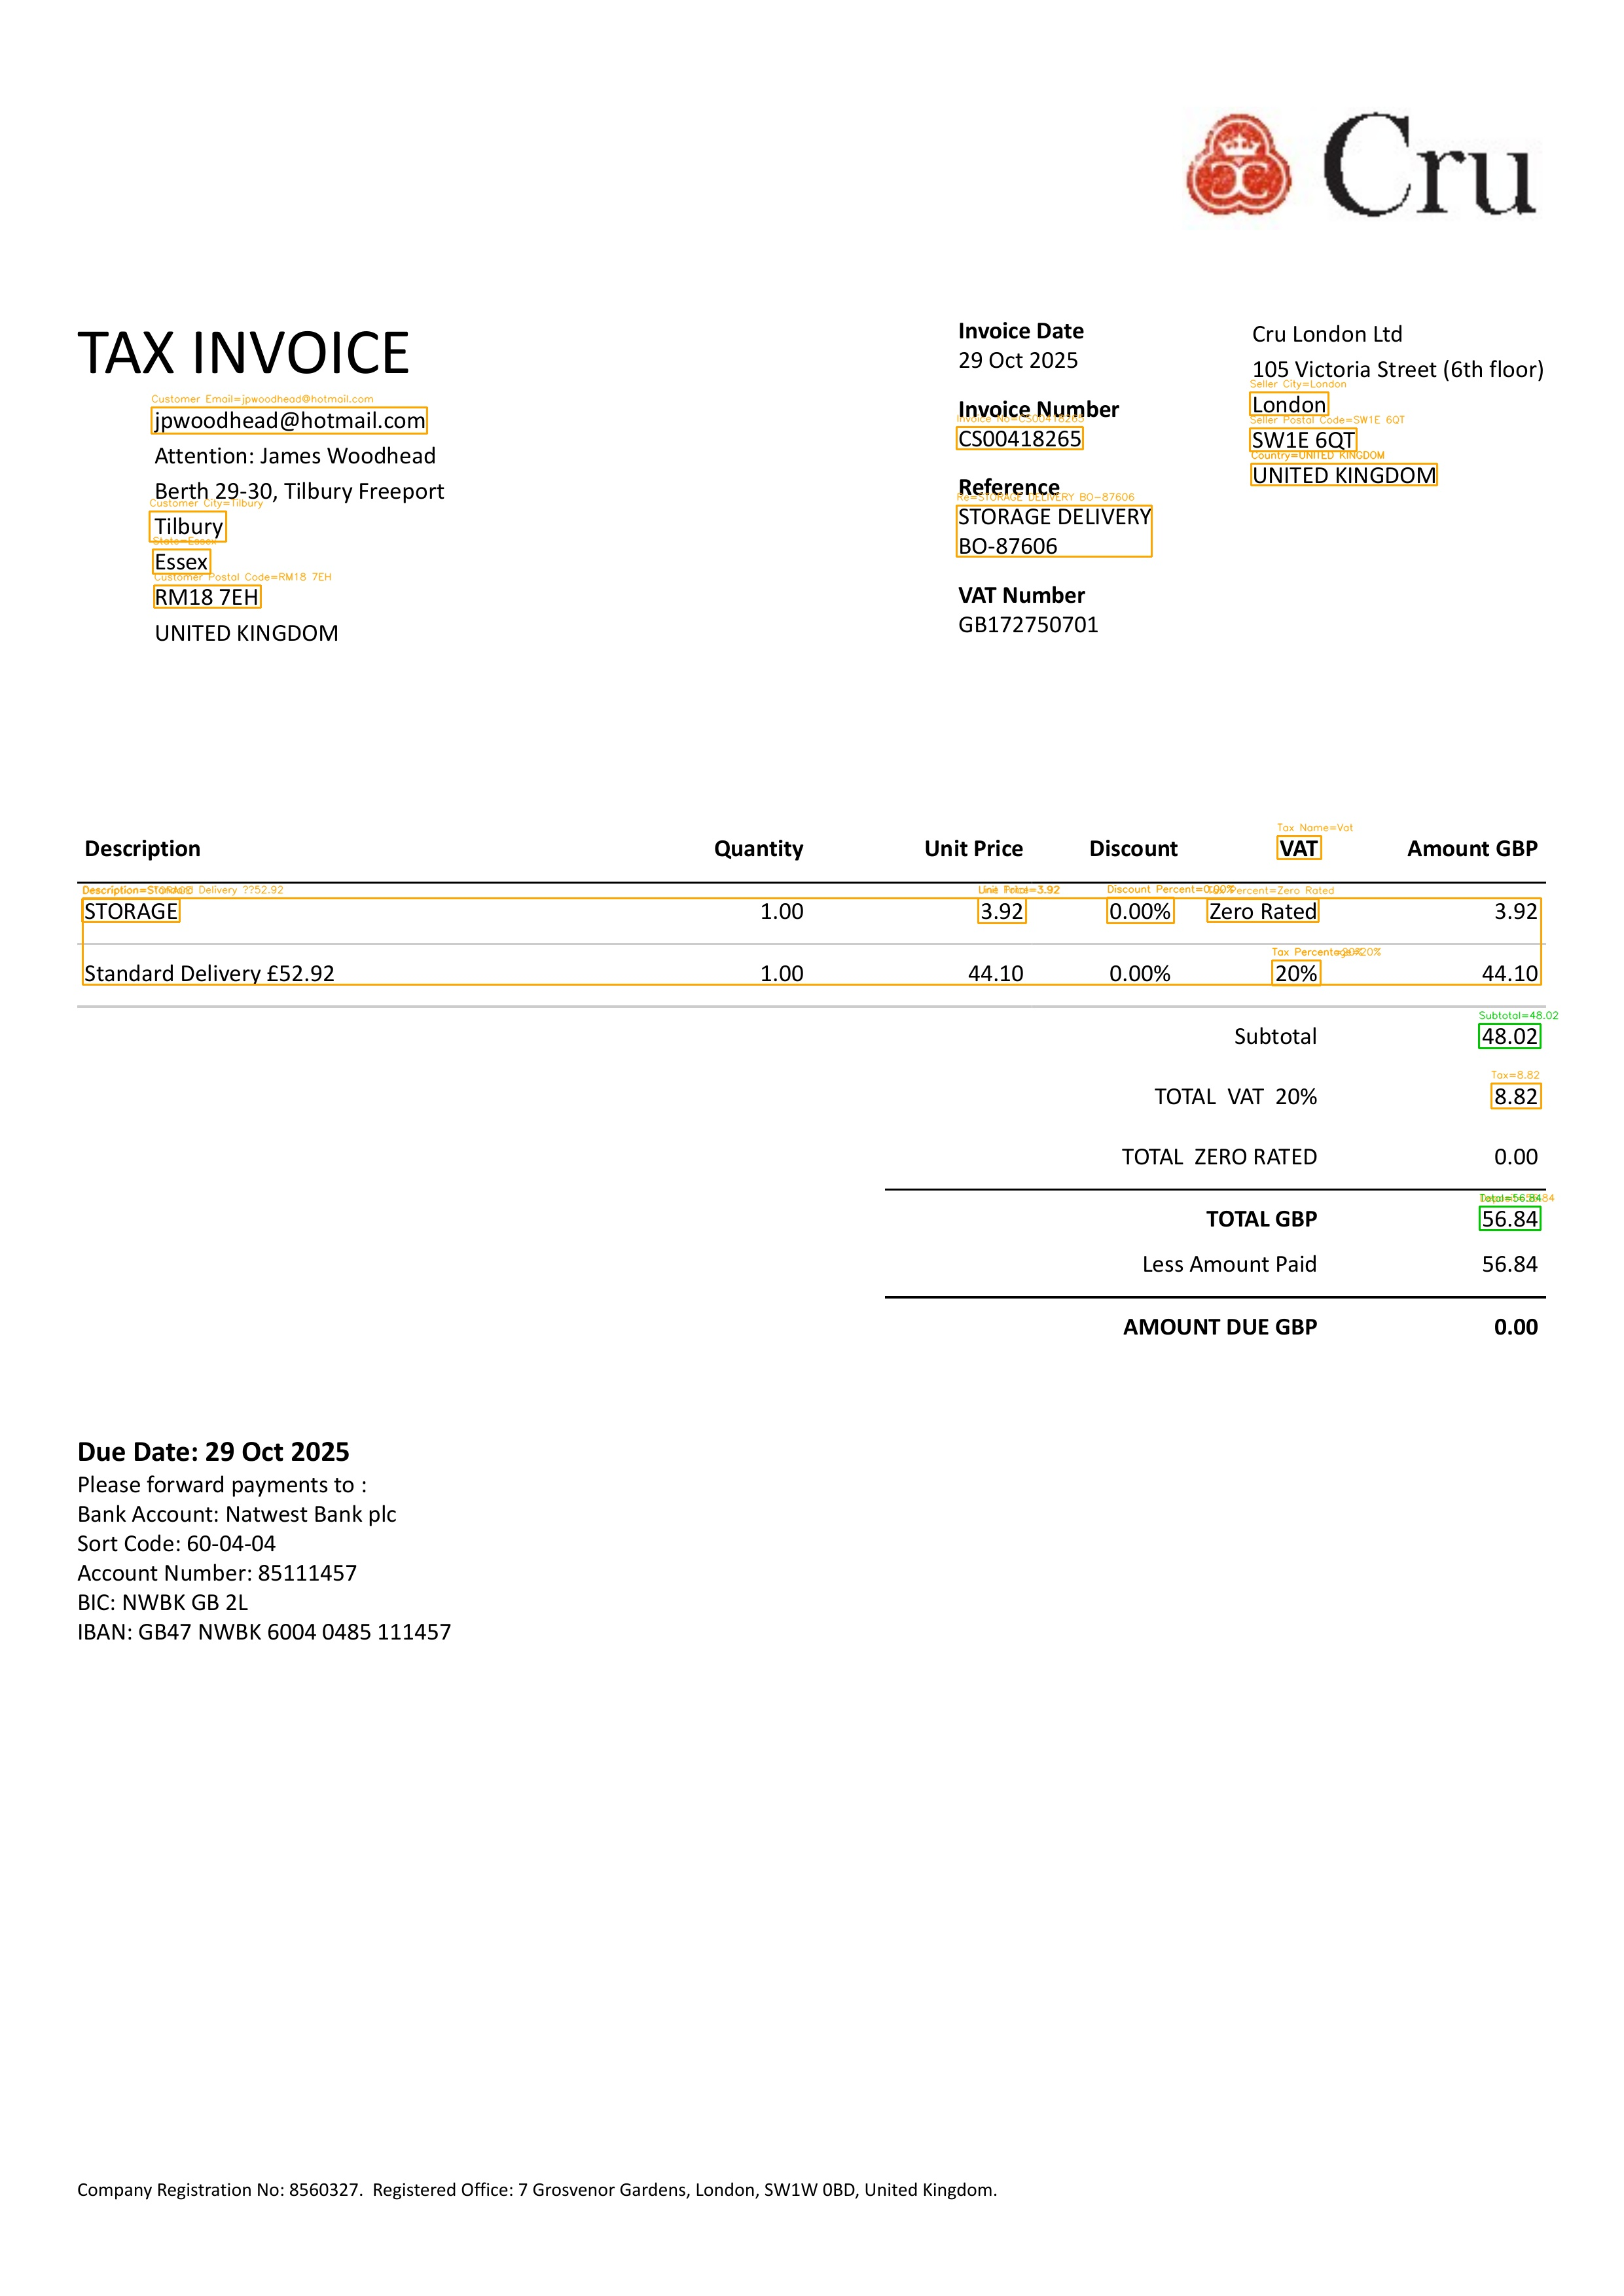

In [13]:
from IPython.display import Image as IPImage, display

display(IPImage(filename=output_image_path))

In [14]:
from google.colab import files

files.download(output_image_path)
files.download("grounding_results.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>